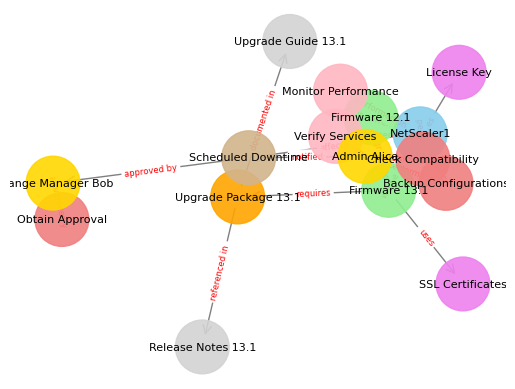

<Figure size 1500x1000 with 0 Axes>

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# Define nodes with attributes
nodes = [
    # NetScaler Instances
    ('NetScaler1', {'type': 'Instance', 'current_version': '12.1', 'model': 'MPX'}),
    ('Firmware 12.1', {'type': 'Firmware', 'version': '12.1'}),
    ('Firmware 13.1', {'type': 'Firmware', 'version': '13.1'}),

    # Upgrade Package
    ('Upgrade Package 13.1', {'type': 'Upgrade Package'}),

    # Pre-Upgrade Tasks
    ('Backup Configurations', {'type': 'Pre-Upgrade Task'}),
    ('Check Compatibility', {'type': 'Pre-Upgrade Task'}),
    ('Obtain Approval', {'type': 'Pre-Upgrade Task'}),

    # Post-Upgrade Tasks
    ('Verify Services', {'type': 'Post-Upgrade Task'}),
    ('Monitor Performance', {'type': 'Post-Upgrade Task'}),

    # Dependencies
    ('License Key', {'type': 'Dependency'}),
    ('SSL Certificates', {'type': 'Dependency'}),

    # Users/Roles
    ('Admin Alice', {'type': 'User'}),
    ('Change Manager Bob', {'type': 'User'}),

    # Documentation
    ('Upgrade Guide 13.1', {'type': 'Documentation'}),
    ('Release Notes 13.1', {'type': 'Documentation'}),

    # Events
    ('Scheduled Downtime', {'type': 'Event'}),
]

# Define edges with relationship labels
edges = [
    # Current firmware
    ('NetScaler1', 'Firmware 12.1', {'relationship': 'is currently running'}),

    # Upgrade path
    ('Firmware 12.1', 'Firmware 13.1', {'relationship': 'upgrades to'}),
    ('NetScaler1', 'Firmware 13.1', {'relationship': 'will be upgraded to'}),

    # Upgrade Package
    ('Firmware 13.1', 'Upgrade Package 13.1', {'relationship': 'requires'}),
    ('Upgrade Package 13.1', 'Upgrade Guide 13.1', {'relationship': 'documented in'}),
    ('Upgrade Package 13.1', 'Release Notes 13.1', {'relationship': 'referenced in'}),

    # Pre-Upgrade Tasks
    ('Backup Configurations', 'NetScaler1', {'relationship': 'performed on'}),
    ('Check Compatibility', 'NetScaler1', {'relationship': 'performed on'}),
    ('Obtain Approval', 'Change Manager Bob', {'relationship': 'approved by'}),

    # Dependencies
    ('Firmware 13.1', 'License Key', {'relationship': 'requires'}),
    ('Firmware 13.1', 'SSL Certificates', {'relationship': 'uses'}),

    # Post-Upgrade Tasks
    ('Verify Services', 'NetScaler1', {'relationship': 'performed on'}),
    ('Monitor Performance', 'NetScaler1', {'relationship': 'performed on'}),

    # Users/Roles
    ('Admin Alice', 'Backup Configurations', {'relationship': 'performs'}),
    ('Admin Alice', 'Check Compatibility', {'relationship': 'performs'}),
    ('Admin Alice', 'Verify Services', {'relationship': 'performs'}),
    ('Admin Alice', 'Monitor Performance', {'relationship': 'performs'}),
    ('Change Manager Bob', 'Obtain Approval', {'relationship': 'oversees'}),

    # Events
    ('Scheduled Downtime', 'NetScaler1', {'relationship': 'affects'}),
    ('Scheduled Downtime', 'Admin Alice', {'relationship': 'notified'}),
    ('Scheduled Downtime', 'Change Manager Bob', {'relationship': 'approved by'}),
]

# Create a directed graph
G = nx.DiGraph()

# Add nodes and edges
G.add_nodes_from(nodes)
G.add_edges_from(edges)

# Define node colors
node_colors = []
for node in G.nodes(data=True):
    node_type = node[1]['type']
    if node_type == 'Instance':
        node_colors.append('skyblue')
    elif node_type == 'Firmware':
        node_colors.append('lightgreen')
    elif node_type == 'Upgrade Package':
        node_colors.append('orange')
    elif node_type == 'Pre-Upgrade Task':
        node_colors.append('lightcoral')
    elif node_type == 'Post-Upgrade Task':
        node_colors.append('lightpink')
    elif node_type == 'Dependency':
        node_colors.append('violet')
    elif node_type == 'User':
        node_colors.append('gold')
    elif node_type == 'Documentation':
        node_colors.append('lightgray')
    elif node_type == 'Event':
        node_colors.append('tan')
    else:
        node_colors.append('white')

# Define edge labels
edge_labels = {(u, v): d['relationship'] for u, v, d in G.edges(data=True)}

# Position nodes using spring layout
pos = nx.spring_layout(G, k=0.5, iterations=50)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1500, alpha=0.9)

# Draw edges
nx.draw_networkx_edges(G, pos, edge_color='gray', arrowstyle='->', arrowsize=15)

# Draw node labels
nx.draw_networkx_labels(G, pos, font_size=8, font_family='sans-serif')

# Draw edge labels
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=6)

# Remove axis
plt.axis('off')

# Set the figure size
plt.figure(figsize=(15, 10))

# Display the graph
plt.show()

In [4]:
from graphviz import Digraph

# Create a directed graph
graph = Digraph('NetScaler Upgrade Knowledge Graph', format='png')
graph.attr(bgcolor='white')

# Define node styles and colors
node_styles = {
    'Instance': {'color': 'skyblue', 'style': 'filled', 'shape': 'box'},
    'Firmware': {'color': 'lightgreen', 'style': 'filled', 'shape': 'box'},
    'Upgrade Package': {'color': 'orange', 'style': 'filled', 'shape': 'box'},
    'Pre-Upgrade Task': {'color': 'lightcoral', 'style': 'filled', 'shape': 'ellipse'},
    'Post-Upgrade Task': {'color': 'lightpink', 'style': 'filled', 'shape': 'ellipse'},
    'Dependency': {'color': 'violet', 'style': 'filled', 'shape': 'ellipse'},
    'User': {'color': 'gold', 'style': 'filled', 'shape': 'box'},
    'Documentation': {'color': 'lightgray', 'style': 'filled', 'shape': 'box'},
    'Event': {'color': 'tan', 'style': 'filled', 'shape': 'ellipse'}
}

# Add nodes
nodes = [
    ('NetScaler1', 'Instance'),
    ('Firmware 12.1', 'Firmware'),
    ('Firmware 13.1', 'Firmware'),
    ('Upgrade Package 13.1', 'Upgrade Package'),
    ('Backup Configurations', 'Pre-Upgrade Task'),
    ('Check Compatibility', 'Pre-Upgrade Task'),
    ('Obtain Approval', 'Pre-Upgrade Task'),
    ('Verify Services', 'Post-Upgrade Task'),
    ('Monitor Performance', 'Post-Upgrade Task'),
    ('License Key', 'Dependency'),
    ('SSL Certificates', 'Dependency'),
    ('Admin Alice', 'User'),
    ('Change Manager Bob', 'User'),
    ('Upgrade Guide 13.1', 'Documentation'),
    ('Release Notes 13.1', 'Documentation'),
    ('Scheduled Downtime', 'Event')
]

for node, node_type in nodes:
    graph.node(node, **node_styles[node_type])

# Add edges
edges = [
    ('NetScaler1', 'Firmware 12.1', 'is currently running'),
    ('Firmware 12.1', 'Firmware 13.1', 'upgrades to'),
    ('NetScaler1', 'Firmware 13.1', 'will be upgraded to'),
    ('Firmware 13.1', 'Upgrade Package 13.1', 'requires'),
    ('Upgrade Package 13.1', 'Upgrade Guide 13.1', 'documented in'),
    ('Upgrade Package 13.1', 'Release Notes 13.1', 'referenced in'),
    ('Backup Configurations', 'NetScaler1', 'performed on'),
    ('Check Compatibility', 'NetScaler1', 'performed on'),
    ('Obtain Approval', 'Change Manager Bob', 'approved by'),
    ('Firmware 13.1', 'License Key', 'requires'),
    ('Firmware 13.1', 'SSL Certificates', 'uses'),
    ('Verify Services', 'NetScaler1', 'performed on'),
    ('Monitor Performance', 'NetScaler1', 'performed on'),
    ('Admin Alice', 'Backup Configurations', 'performs'),
    ('Admin Alice', 'Check Compatibility', 'performs'),
    ('Admin Alice', 'Verify Services', 'performs'),
    ('Admin Alice', 'Monitor Performance', 'performs'),
    ('Change Manager Bob', 'Obtain Approval', 'oversees'),
    ('Scheduled Downtime', 'NetScaler1', 'affects'),
    ('Scheduled Downtime', 'Admin Alice', 'notified'),
    ('Scheduled Downtime', 'Change Manager Bob', 'approved by')
]

for src, dst, label in edges:
    graph.edge(src, dst, label, color='gray')

# Render the graph
graph.render('netscaler_upgrade_knowledge_graph', view=True)

'netscaler_upgrade_knowledge_graph.png'

In [3]:
from graphviz import Digraph

# Create a directed graph for NetScaler Upgrade Knowledge Graph
graph = Digraph('NetScaler Upgrade Knowledge Graph', format='png')
graph.attr(bgcolor='white')

# Define node styles and colors
node_styles = {
    'Instance': {'color': 'skyblue', 'style': 'filled', 'shape': 'box'},
    'Firmware': {'color': 'lightgreen', 'style': 'filled', 'shape': 'box'},
    'Upgrade Package': {'color': 'orange', 'style': 'filled', 'shape': 'box'},
    'Pre-Upgrade Task': {'color': 'lightcoral', 'style': 'filled', 'shape': 'ellipse'},
    'Post-Upgrade Task': {'color': 'lightpink', 'style': 'filled', 'shape': 'ellipse'},
    'Dependency': {'color': 'violet', 'style': 'filled', 'shape': 'ellipse'},
    'User': {'color': 'gold', 'style': 'filled', 'shape': 'box'},
    'Documentation': {'color': 'lightgray', 'style': 'filled', 'shape': 'box'},
    'Event': {'color': 'tan', 'style': 'filled', 'shape': 'ellipse'}
}

# Add nodes
nodes = [
    ('NetScaler1', 'Instance'),
    ('Firmware 12.1', 'Firmware'),
    ('Firmware 13.1', 'Firmware'),
    ('Upgrade Package 13.1', 'Upgrade Package'),
    ('Backup Configurations', 'Pre-Upgrade Task'),
    ('Check Compatibility', 'Pre-Upgrade Task'),
    ('Obtain Approval', 'Pre-Upgrade Task'),
    ('Verify Services', 'Post-Upgrade Task'),
    ('Monitor Performance', 'Post-Upgrade Task'),
    ('License Key', 'Dependency'),
    ('SSL Certificates', 'Dependency'),
    ('Admin Alice', 'User'),
    ('Change Manager Bob', 'User'),
    ('Upgrade Guide 13.1', 'Documentation'),
    ('Release Notes 13.1', 'Documentation'),
    ('Scheduled Downtime', 'Event')
]

for node, node_type in nodes:
    graph.node(node, **node_styles[node_type])

# Add edges
edges = [
    ('NetScaler1', 'Firmware 12.1', 'is currently running'),
    ('Firmware 12.1', 'Firmware 13.1', 'upgrades to'),
    ('NetScaler1', 'Firmware 13.1', 'will be upgraded to'),
    ('Firmware 13.1', 'Upgrade Package 13.1', 'requires'),
    ('Upgrade Package 13.1', 'Upgrade Guide 13.1', 'documented in'),
    ('Upgrade Package 13.1', 'Release Notes 13.1', 'referenced in'),
    ('Backup Configurations', 'NetScaler1', 'performed on'),
    ('Check Compatibility', 'NetScaler1', 'performed on'),
    ('Obtain Approval', 'Change Manager Bob', 'approved by'),
    ('Firmware 13.1', 'License Key', 'requires'),
    ('Firmware 13.1', 'SSL Certificates', 'uses'),
    ('Verify Services', 'NetScaler1', 'performed on'),
    ('Monitor Performance', 'NetScaler1', 'performed on'),
    ('Admin Alice', 'Backup Configurations', 'performs'),
    ('Admin Alice', 'Check Compatibility', 'performs'),
    ('Admin Alice', 'Verify Services', 'performs'),
    ('Admin Alice', 'Monitor Performance', 'performs'),
    ('Change Manager Bob', 'Obtain Approval', 'oversees'),
    ('Scheduled Downtime', 'NetScaler1', 'affects'),
    ('Scheduled Downtime', 'Admin Alice', 'notified'),
    ('Scheduled Downtime', 'Change Manager Bob', 'approved by')
]

for src, dst, label in edges:
    graph.edge(src, dst, label, color='gray')

# Render the graph
graph.render('netscaler_upgrade_knowledge_graph', view=True)

# Create a directed graph for AI-based RAG System Knowledge Graph
rag_graph = Digraph('AI-based RAG System for NetScaler Upgrade', format='png')
rag_graph.attr(bgcolor='white')

# Define node styles and colors for RAG system
rag_node_styles = {
    'Knowledge Base': {'color': 'lightblue', 'style': 'filled', 'shape': 'box'},
    'User Query': {'color': 'gold', 'style': 'filled', 'shape': 'ellipse'},
    'RAG System': {'color': 'lightgreen', 'style': 'filled', 'shape': 'box'},
    'Document Retrieval': {'color': 'orange', 'style': 'filled', 'shape': 'box'},
    'Response Generation': {'color': 'lightpink', 'style': 'filled', 'shape': 'ellipse'},
    'Upgrade Guidance': {'color': 'lightcoral', 'style': 'filled', 'shape': 'box'},
    'Feedback Loop': {'color': 'violet', 'style': 'filled', 'shape': 'ellipse'}
}

# Add nodes for RAG system
rag_nodes = [
    ('User Query', 'User Query'),
    ('RAG System', 'RAG System'),
    ('Knowledge Base', 'Knowledge Base'),
    ('Document Retrieval', 'Document Retrieval'),
    ('Response Generation', 'Response Generation'),
    ('Upgrade Guidance', 'Upgrade Guidance'),
    ('Feedback Loop', 'Feedback Loop')
]

for node, node_type in rag_nodes:
    rag_graph.node(node, **rag_node_styles[node_type])

# Add edges for RAG system
rag_edges = [
    ('User Query', 'RAG System', 'input to'),
    ('RAG System', 'Document Retrieval', 'retrieves from'),
    ('Document Retrieval', 'Knowledge Base', 'accesses'),
    ('RAG System', 'Response Generation', 'generates'),
    ('Response Generation', 'Upgrade Guidance', 'provides'),
    ('Upgrade Guidance', 'User Query', 'answers'),
    ('User Query', 'Feedback Loop', 'feedback to'),
    ('Feedback Loop', 'RAG System', 'improves')
]

for src, dst, label in rag_edges:
    rag_graph.edge(src, dst, label, color='gray')

# Render the RAG system graph
rag_graph.render('ai_rag_system_for_netscaler_upgrade', view=True)

'ai_rag_system_for_netscaler_upgrade.png'

In [2]:
from graphviz import Digraph

# Create a Digraph object
dot = Digraph(comment='NetScaler Upgrade Knowledge Graph', format='png')
dot.attr('node', shape='rectangle', style='filled', fontsize='10', fontname='Helvetica')

# Define colors for different clusters
cluster_colors = {
    'Instances': 'skyblue',
    'Firmware': 'lightgreen',
    'Upgrade Packages': 'orange',
    'Pre-Upgrade Tasks': 'lightcoral',
    'Post-Upgrade Tasks': 'lightpink',
    'Dependencies': 'violet',
    'Users': 'gold',
    'Documentation': 'lightgray',
    'Events': 'tan',
    'Logs & Monitoring': 'lightblue',
}

# Define clusters for different node types
def create_cluster(name, nodes):
    with dot.subgraph(name='cluster_' + name) as c:
        c.attr(label=name, color=cluster_colors.get(name, 'black'), style='filled', fillcolor=cluster_colors.get(name, 'white'))
        for node_id, label in nodes.items():
            c.node(node_id, label=label)

# Nodes definition
create_cluster('Instances', {
    'NetScaler1': 'NetScaler1\nModel: MPX\nCurrent Version: 12.1',
    'NetScaler2': 'NetScaler2\nModel: VPX\nCurrent Version: 12.1',
})

create_cluster('Firmware', {
    'Firmware12.1': 'Firmware 12.1',
    'Firmware13.0': 'Firmware 13.0',
    'Firmware13.1': 'Firmware 13.1',
})

create_cluster('Upgrade Packages', {
    'UpgradePackage13.0': 'Upgrade Package 13.0',
    'UpgradePackage13.1': 'Upgrade Package 13.1',
})

create_cluster('Pre-Upgrade Tasks', {
    'BackupConfigs': 'Backup Configurations',
    'CheckCompatibility': 'Check Compatibility',
    'ObtainApproval': 'Obtain Approval',
    'NotifyUsers': 'Notify Users',
})

create_cluster('Post-Upgrade Tasks', {
    'VerifyServices': 'Verify Services',
    'MonitorPerformance': 'Monitor Performance',
    'UpdateDocumentation': 'Update Documentation',
})

create_cluster('Dependencies', {
    'LicenseKey': 'License Key',
    'SSLCertificates': 'SSL Certificates',
    'NetworkAccess': 'Network Access',
})

create_cluster('Users', {
    'AdminAlice': 'Admin Alice',
    'ChangeManagerBob': 'Change Manager Bob',
    'NetworkTeam': 'Network Team',
})

create_cluster('Documentation', {
    'UpgradeGuide13.1': 'Upgrade Guide 13.1',
    'ReleaseNotes13.1': 'Release Notes 13.1',
    'KnownIssues': 'Known Issues',
})

create_cluster('Events', {
    'ScheduledDowntime': 'Scheduled Downtime',
    'ApprovalGranted': 'Approval Granted',
    'UserNotification': 'User Notification',
})

create_cluster('Logs & Monitoring', {
    'UpgradeLogs': 'Upgrade Logs',
    'SystemLogs': 'System Logs',
    'PerformanceMetrics': 'Performance Metrics',
})

# Edges with labels
edges = [
    # Current firmware
    ('NetScaler1', 'Firmware12.1', 'is currently running'),
    ('NetScaler2', 'Firmware12.1', 'is currently running'),

    # Upgrade paths
    ('Firmware12.1', 'Firmware13.0', 'upgrades to'),
    ('Firmware13.0', 'Firmware13.1', 'upgrades to'),
    ('NetScaler1', 'Firmware13.1', 'will be upgraded to'),
    ('NetScaler2', 'Firmware13.0', 'will be upgraded to'),

    # Upgrade Packages
    ('Firmware13.0', 'UpgradePackage13.0', 'requires'),
    ('Firmware13.1', 'UpgradePackage13.1', 'requires'),
    ('UpgradePackage13.1', 'UpgradeGuide13.1', 'documented in'),
    ('UpgradePackage13.1', 'ReleaseNotes13.1', 'referenced in'),

    # Pre-Upgrade Tasks
    ('BackupConfigs', 'NetScaler1', 'performed on'),
    ('CheckCompatibility', 'NetScaler1', 'performed on'),
    ('ObtainApproval', 'ChangeManagerBob', 'approved by'),
    ('NotifyUsers', 'UserNotification', 'results in'),

    # Dependencies
    ('Firmware13.1', 'LicenseKey', 'requires'),
    ('Firmware13.1', 'SSLCertificates', 'uses'),
    ('Firmware13.1', 'NetworkAccess', 'needs'),

    # Post-Upgrade Tasks
    ('VerifyServices', 'NetScaler1', 'performed on'),
    ('MonitorPerformance', 'NetScaler1', 'performed on'),
    ('UpdateDocumentation', 'Documentation', 'updates'),

    # Users/Roles
    ('AdminAlice', 'BackupConfigs', 'performs'),
    ('AdminAlice', 'CheckCompatibility', 'performs'),
    ('AdminAlice', 'VerifyServices', 'performs'),
    ('AdminAlice', 'MonitorPerformance', 'performs'),
    ('NetworkTeam', 'MonitorPerformance', 'assists with'),
    ('ChangeManagerBob', 'ObtainApproval', 'oversees'),
    ('ChangeManagerBob', 'ApprovalGranted', 'grants'),

    # Events
    ('ScheduledDowntime', 'NetScaler1', 'affects'),
    ('ScheduledDowntime', 'AdminAlice', 'notifies'),
    ('ScheduledDowntime', 'ChangeManagerBob', 'approved by'),

    # Logs & Monitoring
    ('UpgradeLogs', 'SystemLogs', 'integrated into'),
    ('MonitorPerformance', 'PerformanceMetrics', 'collects'),

    # Additional relationships
    ('UpgradeGuide13.1', 'KnownIssues', 'references'),
    ('ReleaseNotes13.1', 'KnownIssues', 'mentions'),
]

# Add edges to the graph
for src, dst, label in edges:
    dot.edge(src, dst, label=label)

# Render the graph
dot.render('netscaler_upgrade_knowledge_graph', view=True)


'netscaler_upgrade_knowledge_graph.png'

In [1]:
from graphviz import Digraph

# Create a Digraph object
dot = Digraph(comment='NetScaler Knowledge Graph', format='png')
dot.attr('node', shape='rectangle', style='filled', fontsize='10', fontname='Helvetica')

# Define colors for different clusters
cluster_colors = {
    'Instances': 'skyblue',
    'Features': 'lightgreen',
    'Configurations': 'orange',
    'Dependencies': 'violet',
    'Users': 'gold',
    'Documentation': 'lightgray',
    'Network Elements': 'lightcoral',
    'Monitoring': 'lightpink',
}

# Define clusters for different node types
def create_cluster(name, nodes):
    with dot.subgraph(name='cluster_' + name) as c:
        c.attr(label=name, color=cluster_colors.get(name, 'black'), style='filled', fillcolor=cluster_colors.get(name, 'white'))
        for node_id, label in nodes.items():
            c.node(node_id, label=label)

# Nodes definition
create_cluster('Instances', {
    'NetScaler1': 'NetScaler1\nModel: MPX\nFirmware: 13.1',
    'NetScaler2': 'NetScaler2\nModel: VPX\nFirmware: 13.0',
})

create_cluster('Features', {
    'LoadBalancing': 'Load Balancing',
    'SSLOffloading': 'SSL Offloading',
    'ContentSwitching': 'Content Switching',
    'GSLB': 'Global Server Load Balancing',
    'Authentication': 'Authentication',
})

create_cluster('Configurations', {
    'VirtualServer1': 'Virtual Server 1\n(Load Balancing)',
    'VirtualServer2': 'Virtual Server 2\n(SSL Offloading)',
    'Policy1': 'Content Switching Policy 1',
    'Profile1': 'SSL Profile 1',
})

create_cluster('Dependencies', {
    'LicenseEnterprise': 'Enterprise License',
    'SSL_Cert1': 'SSL Certificate 1',
    'ExternalAuthServer': 'External Auth Server',
})

create_cluster('Users', {
    'AdminAlice': 'Admin Alice\nRole: Super Admin',
    'OperatorBob': 'Operator Bob\nRole: Network Operator',
})

create_cluster('Documentation', {
    'ConfigGuideLB': 'Config Guide - Load Balancing',
    'BestPracticesSSL': 'Best Practices - SSL',
})

create_cluster('Network Elements', {
    'BackendServer1': 'Backend Server 1',
    'BackendServer2': 'Backend Server 2',
    'ClientNetwork': 'Client Network',
    'DMZInterface': 'DMZ Interface',
})

create_cluster('Monitoring', {
    'SysLogs': 'System Logs',
    'MetricsDashboard': 'Metrics Dashboard',
    'Alerts': 'Alerts',
})

# Edges with labels
edges = [
    # Instances and Features
    ('NetScaler1', 'LoadBalancing', 'supports'),
    ('NetScaler1', 'SSLOffloading', 'supports'),
    ('NetScaler1', 'ContentSwitching', 'supports'),
    ('NetScaler2', 'GSLB', 'supports'),
    ('NetScaler2', 'Authentication', 'supports'),
    
    # Features and Configurations
    ('LoadBalancing', 'VirtualServer1', 'configured with'),
    ('SSLOffloading', 'VirtualServer2', 'configured with'),
    ('ContentSwitching', 'Policy1', 'uses'),
    ('SSLOffloading', 'Profile1', 'applies'),
    
    # Configurations and Dependencies
    ('VirtualServer2', 'SSL_Cert1', 'uses'),
    ('Profile1', 'SSL_Cert1', 'includes'),
    ('Authentication', 'ExternalAuthServer', 'integrates with'),
    ('NetScaler1', 'LicenseEnterprise', 'requires'),
    ('NetScaler2', 'LicenseEnterprise', 'requires'),
    
    # Configurations and Network Elements
    ('VirtualServer1', 'BackendServer1', 'load balances'),
    ('VirtualServer1', 'BackendServer2', 'load balances'),
    ('VirtualServer2', 'BackendServer2', 'offloads SSL to'),
    ('ClientNetwork', 'NetScaler1', 'accesses'),
    ('NetScaler1', 'DMZInterface', 'connects via'),
    
    # Users and Instances
    ('AdminAlice', 'NetScaler1', 'manages'),
    ('OperatorBob', 'NetScaler2', 'monitors'),
    
    # Documentation
    ('ConfigGuideLB', 'LoadBalancing', 'documents'),
    ('BestPracticesSSL', 'SSLOffloading', 'covers'),
    
    # Monitoring
    ('NetScaler1', 'SysLogs', 'generates'),
    ('NetScaler1', 'MetricsDashboard', 'provides data to'),
    ('Alerts', 'AdminAlice', 'notifies'),
    ('Alerts', 'OperatorBob', 'notifies'),
    
    # Dependencies between Network Elements
    ('BackendServer1', 'DMZInterface', 'connected via'),
    ('BackendServer2', 'DMZInterface', 'connected via'),
    
    # Additional relationships
    ('SysLogs', 'Alerts', 'triggers'),
    ('MetricsDashboard', 'OperatorBob', 'viewed by'),
]

# Add edges to the graph
for src, dst, label in edges:
    dot.edge(src, dst, label=label)

# Render the graph
dot.render('netscaler_knowledge_graph', view=True)


'netscaler_knowledge_graph.png'